# Using TrackFormat for Data Import

In addition to the format-specific methods (`readFromCsv()`, `readFromGpx()`, and `readFromWkt()`), Tracklib provides a generic way to import track data using a `TrackFormat`.

A `TrackFormat` describes the structure of the input data independently of the underlying file format. Once defined, data can be loaded using a single generic method:

```python
TrackReader.readFromFile(path, track_format)
```

A `TrackFormat` is a dictionary-like object that describes the layout of the input data. It gathers all import options into a single configuration, making them easier to reuse across multiple datasets.


## Parameters

### General
- `ext`: `ext`: file format (`CSV`, `GPX`, or `WKT`). This parameter is mandatory and determines how files with the corresponding extension are read and written. The default value is `CSV`.

### Coordinates

- `id_E`: index (starting from 0) of the column containing the X coordinate (ECEF), longitude (GEO), or East coordinate (ENU).
- `id_N`: index (starting from 0) of the column containing the Y coordinate (ECEF), latitude (GEO), or North coordinate (ENU).
- `id_U`: index (starting from 0) of the column containing the Z coordinate (ECEF), height, or altitude.
- `srid`: coordinate reference system of the input points (`ENU`, `Geo`, or `ECEF`).

### Time

- `id_T`: index (starting from 0) of the column containing the timestamp (either as Unix time or formatted according to `time_fmt`).
- `date_ini`: reference date (epoch) used when timestamps are stored as elapsed time. Ignored if set to `-1`.
- `time_unit`: unit of the timestamps (seconds, milliseconds, microseconds, or nanoseconds).
- `time_fmt`: format string used to parse textual timestamps (see `ObsTime`).

### CSV Parsing

- `separator`: field separator. Predefined values are `c` (comma), `b` (blank space), and `s` (semicolon). Custom separators are also supported.
- `header`: number of header lines to skip.
- `cmt`: comment prefix. Lines starting with this character are ignored.
- `doublequote`: if `True`, escaped double quotes are handled correctly.
- `encoding`: text encoding of the input file (default: `"utf-8"`).
- `no_data_value`: value indicating an invalid record, which will be skipped during import.
  
### Analytical Features
 
- `read_all`:  if `True`, all remaining columns are imported as `AnalyticalFeature`s.

### Track Identification

- `id_user`: index of the column containing the user identifier (`-1` if not used).
- `id_track`: index of the column containing the track identifier (`-1` if not used).
  

## Complete CSV Example

The following example shows how to load track data from a CSV file with:

- coordinates in a geographic coordinate system,
- timestamps stored in milliseconds since the Unix epoch,
- a spatial filter that keeps only observations within a specified rectangular bounding box.

Code running in a no shapely environment


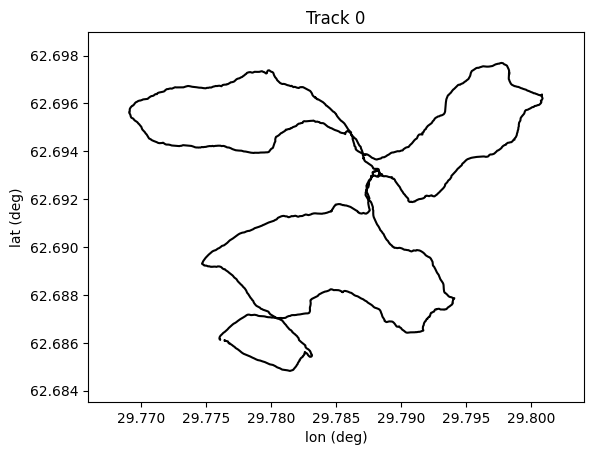

In [1]:
import matplotlib.pyplot as plt

import os
import sys

# Import the Tracklib library
import tracklib as tkl

resource_path = '../../../data/mopsi/wgs84/'
filepath = os.path.join(resource_path, '1412412627743')

tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")
initialDate = '1970-01-01 00:00:00'

Xmin = 29.76
Xmax = 29.81
Ymin = 62.68
Ymax = 62.70
ll = tkl.ENUCoords(Xmin, Ymin)
ur = tkl.ENUCoords(Xmax, Ymax)
bbox = tkl.Rectangle(ll, ur)
constraintBBox = tkl.Constraint(shape = bbox, mode = tkl.MODE_INSIDE, type=tkl.TYPE_CUT_AND_SELECT)
s = tkl.Selector([constraintBBox])

param = tkl.TrackFormat({'ext': 'CSV',
                     'id_E': 1,
                     'id_N': 0,
                     'id_T': 2,
                     'srid': 'Geo',
                     'time_ini': tkl.ObsTime.readTimestamp(initialDate),
                     'time_unit': 0.001,
                     'selector': s,
                     'separator': ' '})
collection = tkl.TrackReader.readFromFile(filepath, param, verbose=False)
collection.plot()